# Deforestation in Harz Mountain Region
## Introduction
Harz National Park and its surrounding environment has suffered an infestation of bark beetles over the past decade. This has led to the widespread loss of the native Norway spruce population. The purpose of this study is to examine the effects of this beetle on the loss of forest and the level of species diveristy within the area.  

To accomplish this, remote sensing data is gathered from the EOPF provided by Copernicus, an association of the European Space Agency. EOPF is intended to be a centralized and convenient cloud platform for researchers that focuses on cloud-native formats such as the ZARR file format. This notebook extensively uses both the cloud data resources as well as the ZARR file format.

### Literature Review

### Initialization and Setup

In [1]:
import warnings
import os
import sys
import logging
from pathlib import Path

sys.path.append(str(Path(os.getcwd()).parent))
warnings.filterwarnings("ignore", category=DeprecationWarning, module="pystac")

from shapely import geometry
from pystac_client import Client
import geopandas as gpd
from distributed import LocalCluster
import matplotlib.pyplot as plt

import pandas as pd
import xarray as xr
import zarr
import dask.array as da


### Own modules
from modules.utils import to_km2, plot_rgb_ndvi
from modules.data_load import (
    get_epsg_from_first_band,
    load_sentinel_data,
    load_sentinel_scl,
    validate_scl,
)
from modules.monoculture import (
    spectral_spatial_std,
    spectral_entropy,
    ndvi_texture,
    forest_monoculture_index,
    spectral_texture,
)


logging.basicConfig()
logger = logging.getLogger(__name__)

In [2]:
# Create local processing cluster
cluster = LocalCluster()
client = cluster.get_client()

In [3]:

harz_boundaries = gpd.read_file("../resources/Nationalpark_Harz_boundaries.geojson")
#bbox = harz_boundaries.geometry.values[0].bounds
bbox = [10.563869,51.773247,10.672531,51.832339]

bbox_polygon = geometry.box(*bbox)
polygon = gpd.GeoDataFrame(index=[0], crs="epsg:4326", geometry=[bbox_polygon])

In [4]:
catalog = Client.open("https://stac.core.eopf.eodc.eu")

### Loading and Preparing Data
CloudCover is in properties, so we can select it from here.

In [5]:
START_YEAR = 2015
END_YEAR = 2026
years = range(START_YEAR, END_YEAR)

In [6]:
r10m = load_sentinel_data(
    catalog=catalog,
    years=years,
    bbox=bbox,
    collection="sentinel-2-l2a",
    asset="SR_10m",
    max_cloud_cover=30
)

In [7]:
r20m = load_sentinel_data(
    catalog=catalog,
    years=years,
    bbox=bbox,
    collection="sentinel-2-l2a",
    asset="SR_20m",
    max_cloud_cover=30
)

In [8]:
scl20m = load_sentinel_scl(
    catalog=catalog,
    years=years,
    bbox=bbox,
    collection="sentinel-2-l2a",
    asset="SCL_20m",
    max_cloud_cover=30
)

In [9]:
epsg = get_epsg_from_first_band(r10m)

bbox_reproj = polygon.to_crs("epsg:" + str(epsg)).geometry.values[0].bounds

x_slice = slice(bbox_reproj[0], bbox_reproj[2])  # ~100 pixels
y_slice = slice(bbox_reproj[3], bbox_reproj[1])  # ~100 pixels

#### Data Combination & Time Series
Search for data from June 1 to August 30 for every year in the study (2018-2025). Filter for images with less than 30% cloud cover, and pick the least cloudy item. Iterate through each item and load the scene classification layer at 20 meter resolution. Convert ZARR to xarray DataArray and add the time dimension.  

In [10]:
from zarr.errors import PathNotFoundError

## TODO: SCL Drop anything, but forest in the SCL Classification
def get_item_for_year(year):
    results = catalog.search(
        collections=["sentinel-2-l2a"],
        bbox=bbox,
        datetime=[f"{year}-06-01", f"{year}-08-30"],
        query={"eo:cloud_cover": {"lt": 30}},  # optional filter
    )
    items = results.item_collection()
    if not items:
        return None

    # pick least cloudy item to get better images.
    best_item = min(items, key=lambda x: x.properties.get("eo:cloud_cover", 999))

    logging.info(f"{year}: selected item with cloud cover = {best_item.properties.get("eo:cloud_cover", "unknown")}%")

    return best_item

items = [
    item for year in years
    if (item := get_item_for_year(year)) is not None
]
scl_datasets = []



for item in items:
    try:
        href = item.assets["SCL_20m"].href

        # Explicit guard for empty / missing paths
        if not href:
            raise PathNotFoundError("Empty SCL_20m href")

        scl_z = zarr.open(href, mode="r")

        # Convert Zarr array to xarray DataArray
        scl_da = xr.DataArray(
            scl_z,
            dims=("y", "x"),  # adjust if your dimensions differ
            name="SCL",
        )

    except (PathNotFoundError, FileNotFoundError, OSError, KeyError, ValueError):
        # Optional logging:
        logging.warning(f"Skipping missing SCL_20m asset for item {item.id}")
        continue

    # Add time dimension
    scl_da = scl_da.expand_dims(
        time=[pd.to_datetime(item.datetime).tz_localize(None)]
    )

    scl_datasets.append(scl_da)

# ----------------------------------------------------------------------
# 5. Combine all datasets into a single time stack
# ----------------------------------------------------------------------
scl20m = xr.concat(scl_datasets, dim="time", join="outer")

#### Reflectances & NDVI
Calculate the NDVI based off the data of the 10 meter reflectance observations. Filter for cloudless observations and calculate the yearly average for a given location.

In [11]:
from datetime import datetime

# Stack bands and NDVI, scale to match Sentinel Hub
# Not sure if we need to concat in this way? can keep it as data arrays in the dataset may be here??
reflectances_r10m = r10m

reflectances_r10m["ndvi"] = (reflectances_r10m.b08 - reflectances_r10m.b04) / (reflectances_r10m.b08 + reflectances_r10m.b04)

#TODO: Take EPSG from satellite data
#TODO: Check, whether every offset and scale matches.

cloudless_bands_ndvi = reflectances_r10m.sel(
    time=datetime(2018, 6, 4), method="nearest"
)

region = cloudless_bands_ndvi.sel(x=x_slice, y=y_slice).chunk(
    {"y": "auto", "x": "auto"}
)

ndvi_region = region["ndvi"].compute()

yearly_ds = (
    reflectances_r10m.sel(x=x_slice, y=y_slice)
    .groupby("time.year")
    .mean(dim="time", skipna=True)
)

/home/randy/Documents/MS_Geoinformatics/Study-Project-EOPF/harz-deforestation-eopf/.venv/lib/python3.12/site-packages/dask/_task_spec.py:759: RuntimeWarning: divide by zero encountered in divide
  return self.func(*new_argspec)


/home/randy/Documents/MS_Geoinformatics/Study-Project-EOPF/harz-deforestation-eopf/.venv/lib/python3.12/site-packages/dask/_task_spec.py:759: RuntimeWarning: divide by zero encountered in divide
  return self.func(*new_argspec)
/home/randy/Documents/MS_Geoinformatics/Study-Project-EOPF/harz-deforestation-eopf/.venv/lib/python3.12/site-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/home/randy/Documents/MS_Geoinformatics/Study-Project-EOPF/harz-deforestation-eopf/.venv/lib/python3.12/site-packages/dask/_task_spec.py:759: RuntimeWarning: divide by zero encountered in divide
  return self.func(*new_argspec)


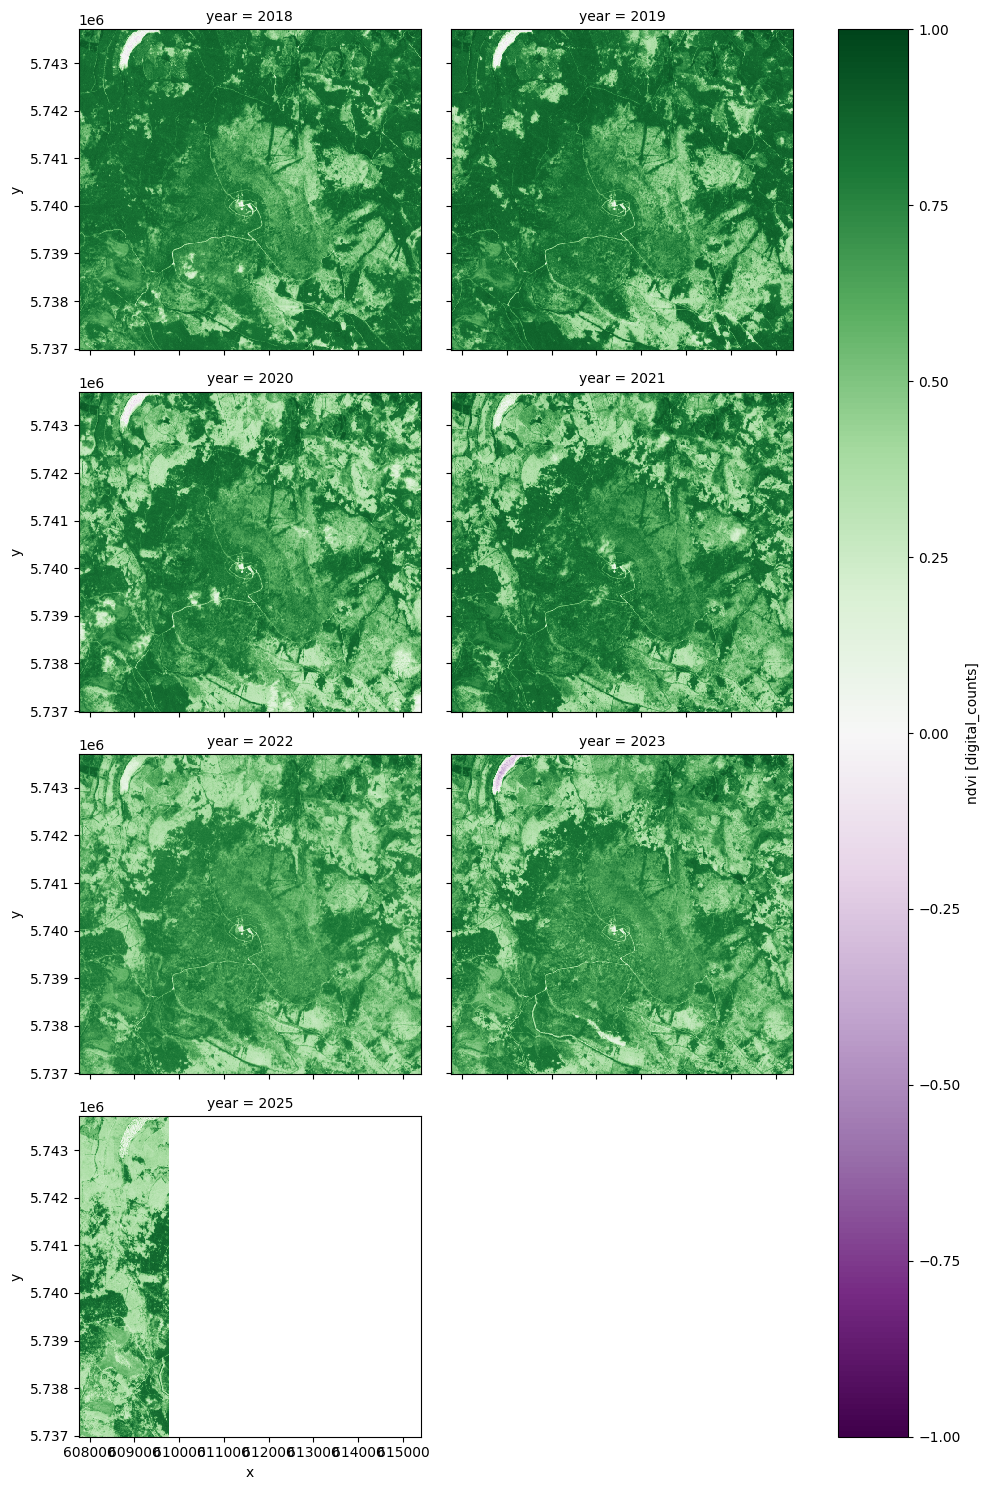

In [12]:
ndvi_yearly = yearly_ds["ndvi"].sel(x=x_slice, y=y_slice).sel(
    year=slice(START_YEAR, END_YEAR)
)

ndvi_yearly.plot(
    cmap="PRGn", x="x", y="y", col="year", col_wrap=2, vmin=-1, vmax=1, figsize=(10, 15)
)

## Analysis

### Forest Cover
Calculate the forest cover by filtering pixels with NDVI greater that 0.7. Compare the resulting areas across years to find the loss of forest coverage. Visualize the loss with image comparison and a trendline.

In [13]:
yearly_ds.ndvi.load()
yearly_ds["FOREST"] = yearly_ds.ndvi > 0.7


#TODO: Remove resolution variable in favor of slice-size
resolution = (100, 100)
forest_pixels = yearly_ds.sel(x=x_slice, y=y_slice).FOREST.sum(["x", "y"])
forest_area_km2 = to_km2(forest_pixels, resolution)

/home/randy/Documents/MS_Geoinformatics/Study-Project-EOPF/harz-deforestation-eopf/.venv/lib/python3.12/site-packages/dask/_task_spec.py:759: RuntimeWarning: divide by zero encountered in divide
  return self.func(*new_argspec)


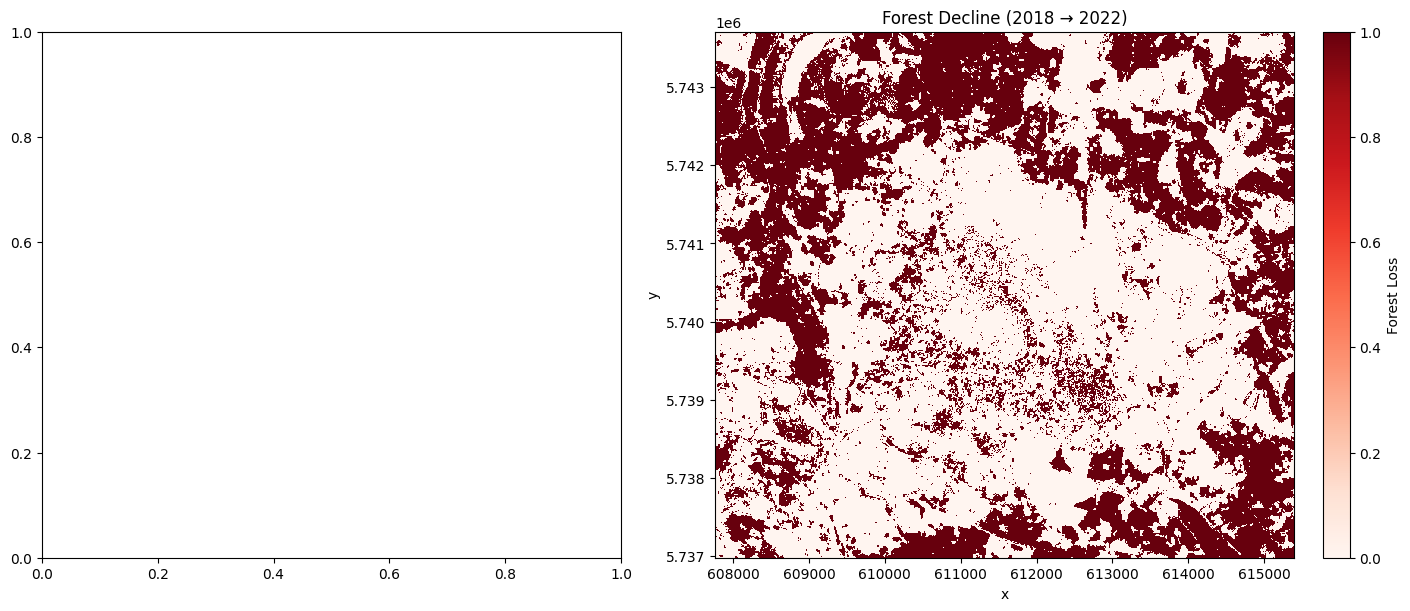

In [14]:
forest_2018 = yearly_ds.FOREST.sel(year=2018)
forest_2022 = yearly_ds.FOREST.sel(year=2022)
forest_decline = forest_2018 & (~forest_2022)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

forest_decline.plot(
    ax=axes[1],
    cmap="Reds",
    cbar_kwargs={"label": "Forest Loss"}
)
axes[1].set_title("Forest Decline (2018 → 2022)")

plt.show()

#TODO: Can there be so many areas with no change in forestry? I guess, there always must be some change.


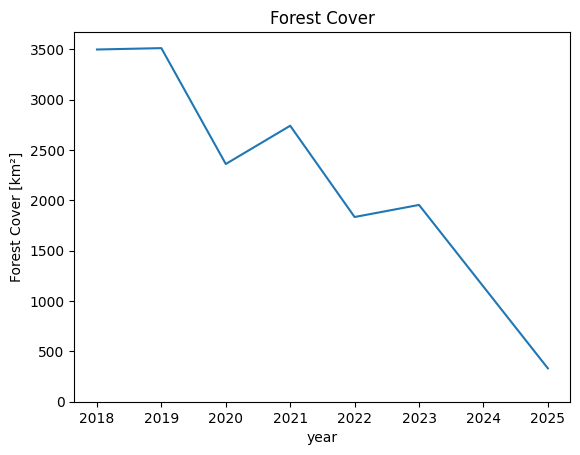

In [15]:
forest_area_km2.load() #Lazy loading
forest_area_km2.plot()


#TODO: Change tracking, show difference in marginality
plt.title("Forest Cover")
plt.ylabel("Forest Cover [km²]")
plt.ylim(0);

### Variance Computing for detecting monoculture
Calculate the NDVI variance over time to estimate the likeliness of a monoculture at a point. If the NDVI does not vary over time, it is likely a monoculture. Conversely, a high variance can signal the presence of more diverse vegetation.  
Spatial variance is computed as well as temporal variance.

#### Temporal NDVI Variance

In [16]:
#Basic NDVI-Variance


ndvi = yearly_ds["ndvi"].sel(x=x_slice, y=y_slice).sel(
    year=2021)

ndvi_var = (
    ndvi
    .rolling(x=5, y=5, center=True)
    .var()
)
ndvi_mean = (
    ndvi
    .rolling(x=5, y=5, center=True)
    .mean()
)

ndvi_cv = ndvi_var / ndvi_mean #Normalized with mean


#TODO: Aggregate over time? Probably even get better results in winter, because the trees might not be obstructing? What would we take then instead of NDVI? --> Take more than one image.


monoculture_mask = ndvi_cv < 0.05 #Example


#Different Windows to get a better view on uniformity

cv_3 = ndvi.rolling(x=3, y=3, center=True).var() / ndvi.rolling(x=3, y=3, center=True).mean()
cv_7 = ndvi.rolling(x=7, y=7, center=True).var() / ndvi.rolling(x=7, y=7, center=True).mean()

cv_combined = (cv_3 + cv_7) / 2

#### Spatial Variance and Texture
We want to determine the monoculture from per pixel NDVI

In [17]:
spectral_spatial_std_ds = spectral_spatial_std(yearly_ds)
spectral_entropy_ds = spectral_entropy(yearly_ds)
ndvi_texture_ds = ndvi_texture(yearly_ds)

forest_mono_index_ds = forest_monoculture_index(
    spectral_spatial_std_ds,
    spectral_entropy_ds,
    ndvi_texture_ds,
)

forest_mono_ds = forest_mono_index_ds > 0.75

spectral_texture_ds = spectral_texture(yearly_ds)

##### Variance & Texture Inputs

2026-02-02 12:25:19,365 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 758.64 MiB -- Worker memory limit: 1.05 GiB
2026-02-02 12:25:20,353 - distributed.worker.memory - WARNING - Worker is at 80% memory usage. Pausing worker.  Process memory: 867.72 MiB -- Worker memory limit: 1.05 GiB
2026-02-02 12:25:20,556 - distributed.worker.memory - WARNING - Worker is at 70% memory usage. Resuming worker. Process memory: 753.33 MiB -- Worker memory limit: 1.05 GiB
2026-02-02 12:25:20,660 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanage

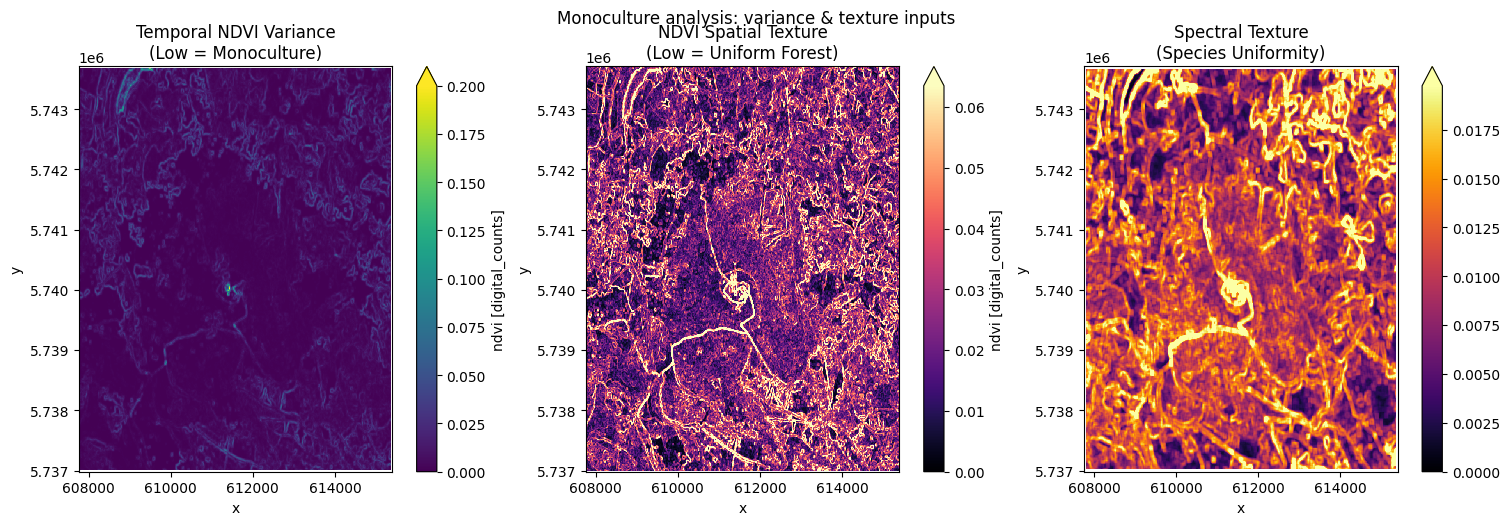

In [18]:
# --- Group: Variance & texture inputs ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

cv_combined.plot(ax=axes[0], cmap="viridis", vmin=0, vmax=0.2)
axes[0].set_title("Temporal NDVI Variance\n(Low = Monoculture)")

vmax_ndvi = ndvi_texture_ds.quantile(0.95).compute()
ndvi_texture_ds.plot(ax=axes[1], cmap="magma", vmin=0, vmax=vmax_ndvi)
axes[1].set_title("NDVI Spatial Texture\n(Low = Uniform Forest)")

vmax_spec = spectral_texture_ds.quantile(0.95).compute()
spectral_texture_ds.plot(ax=axes[2], cmap="inferno", vmin=0, vmax=vmax_spec)
axes[2].set_title("Spectral Texture\n(Species Uniformity)")

plt.suptitle("Monoculture analysis: variance & texture inputs", fontsize=12, y=1.02)
plt.show()

##### Monoculture Index & Candidates

In [19]:
mono_candidate = ndvi_texture_ds < ndvi_texture_ds.quantile(0.15)

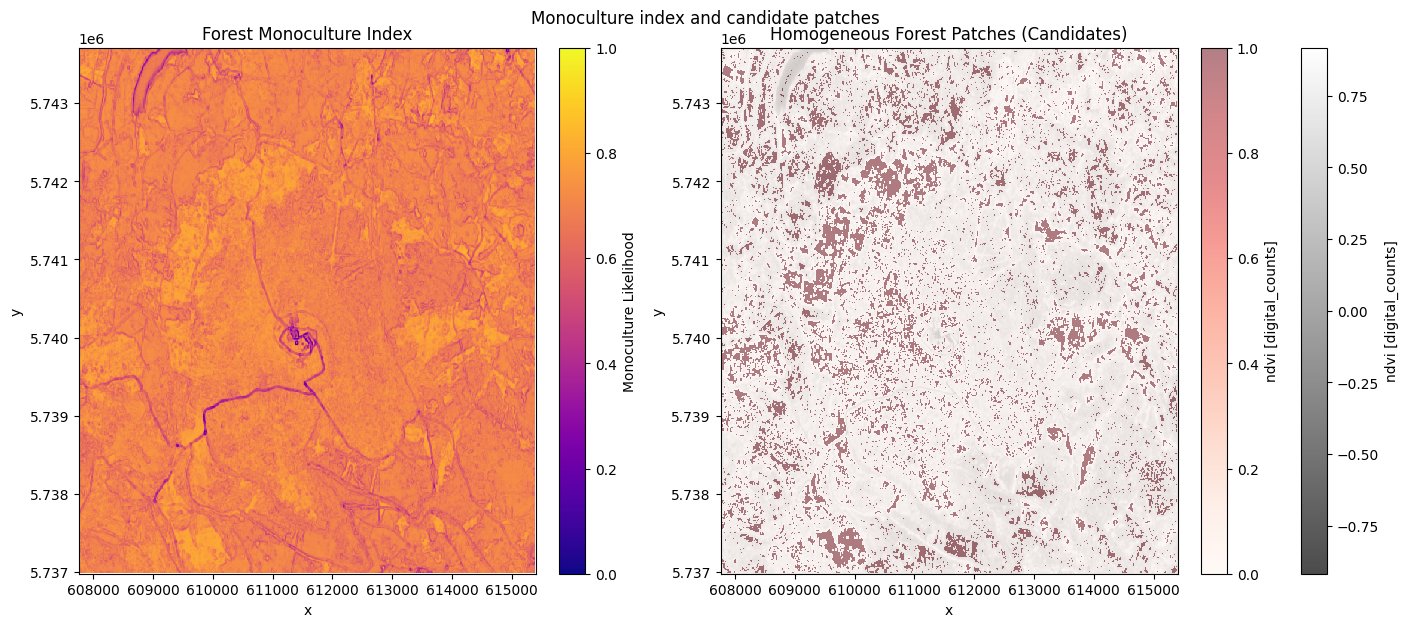

In [20]:
# --- Group: Monoculture index & candidates ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

forest_mono_index_ds.plot(
    ax=axes[0],
    cmap="plasma",
    vmin=0,
    vmax=1,
    cbar_kwargs={"label": "Monoculture Likelihood"}
)
axes[0].set_title("Forest Monoculture Index")

yearly_ds.ndvi.mean("year").plot(ax=axes[1], cmap="gray", alpha=0.7)
mono_candidate.plot(ax=axes[1], cmap="Reds", alpha=0.5)
axes[1].set_title("Homogeneous Forest Patches (Candidates)")

plt.suptitle("Monoculture index and candidate patches", fontsize=12, y=1.02)
plt.show()

##### Forest-Only Index

In [32]:
cutoff = 0.6 #Has to be defined by hand, because we can't automate what we see. Maybe it would be possibly, if we look at the density --> Technically these are outliers.
forest_only = forest_mono_index_ds.where(forest_mono_index_ds >= cutoff)

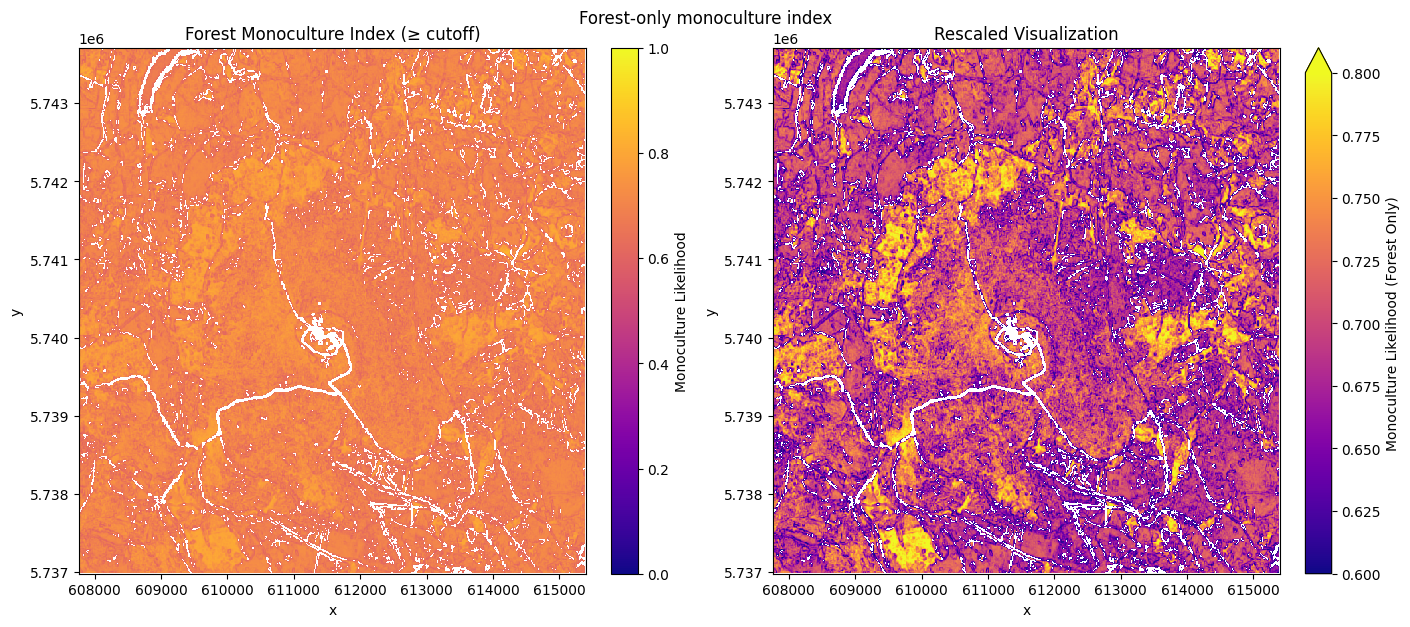

In [22]:
# --- Group: Forest-only monoculture index ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

forest_only.plot(
    ax=axes[0],
    cmap="plasma",
    vmin=0,
    vmax=1,
    cbar_kwargs={"label": "Monoculture Likelihood"}
)
axes[0].set_title("Forest Monoculture Index (≥ cutoff)")

forest_only.plot(
    ax=axes[1],
    cmap="plasma",
    vmin=cutoff,
    vmax=0.8,
    cbar_kwargs={"label": "Monoculture Likelihood (Forest Only)"}
)
axes[1].set_title("Rescaled Visualization")

plt.suptitle("Forest-only monoculture index", fontsize=12, y=1.02)
plt.show()

##### 2018 vs. Multi-Year Index

Nice! We can actually even see here, now with the rescaling, that there are patches of forest, which are more likely to be monoculture.

In [41]:
# Would be nice to get a mask that ignores roads and human built structures.
forest_mask = forest_only.notnull()

# Use mask on other datasets like this.
ndvi_forest_masked = ndvi.where(forest_mask)

Sanity check: Pathways are shown as extremely monoculture likely, so that checks out.
TODO: Remove these pixels with a mask?


In [34]:
forest_mono_index_ds_2018 = forest_monoculture_index(
    spectral_spatial_std(yearly_ds, year=2018),
    spectral_entropy(yearly_ds, year=2018),
    ndvi_texture(yearly_ds, year=2018),
)

forest_only_2018 = forest_mono_index_ds_2018.where(forest_mono_index_ds >= cutoff)

Text(0.5, 1.02, 'Forest Monoculture Index: 2018 vs multi-year')

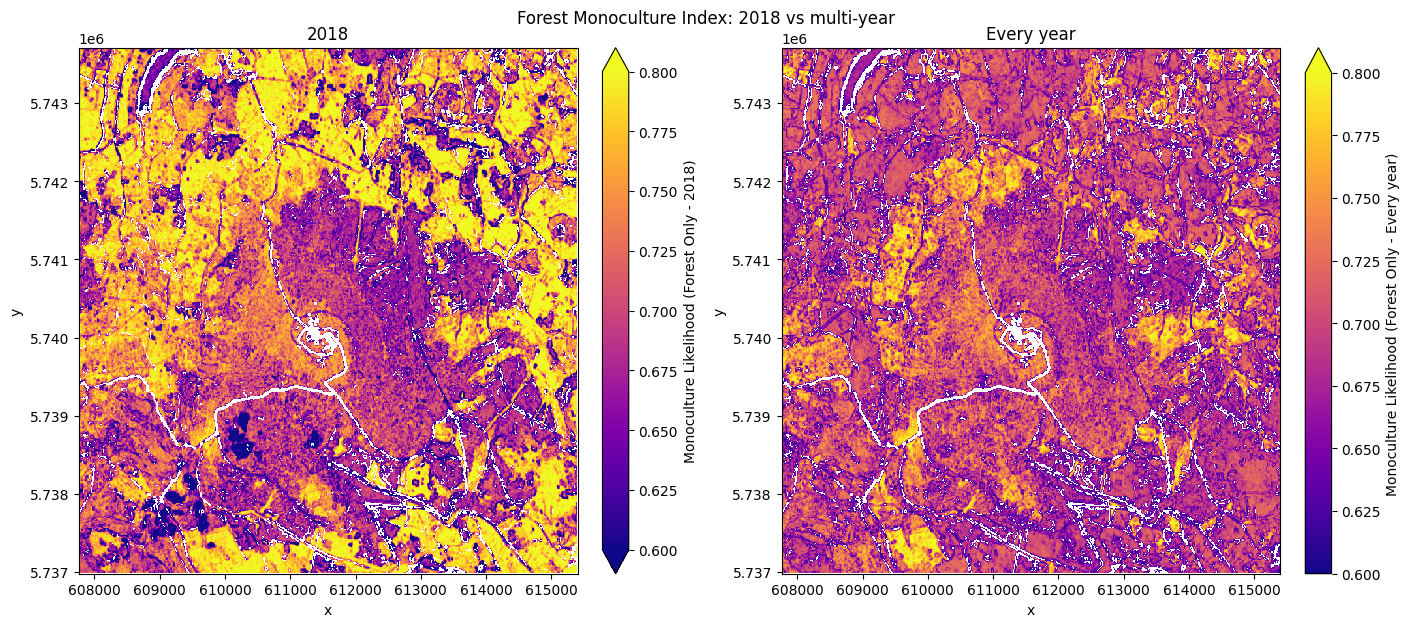

In [36]:
# --- Group: 2018 vs multi-year monoculture index ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

forest_only_2018.plot(
    ax=axes[0],
    cmap="plasma",
    vmin=cutoff,
    vmax=0.8,
    cbar_kwargs={"label": "Monoculture Likelihood (Forest Only - 2018)"}
)
axes[0].set_title("2018")

forest_only.plot(
    ax=axes[1],
    cmap="plasma",
    vmin=cutoff,
    vmax=0.8,
    cbar_kwargs={"label": "Monoculture Likelihood (Forest Only - Every year)"}
)
axes[1].set_title("Every year")

plt.suptitle("Forest Monoculture Index: 2018 vs multi-year", fontsize=12, y=1.02)

##### Mono Vs. Non-Mono Outcome

Works! You can see, that even in the data, there isn't even enough forest gain to justify a schedule.
This means, that the area we identified as monoculture candidates were likely monoculture candidates as they all suffered substantial loss.

Let's also look at the area which is not classified as monoculture.

In [26]:
mono_mask_2018 = forest_only_2018 > 0.77 # This is taken from the example and varied a bit, to see what is considered a forest.

#Apply mask to NDVI from 2022, as this was the worst year.
ndvi_texture_2022 = ndvi_texture(yearly_ds, year=2022, window=1)

ndvi_with_monoculture_areas = forest_decline.where(mono_mask_2018)
ndvi_with_non_monoculture_areas = forest_decline.where(~mono_mask_2018)

In [38]:
def loss_percentage(masked_decline_da):
    loss_pixels = masked_decline_da.sum(["x", "y"])
    reference_pixels = masked_decline_da.notnull().sum(["x", "y"])
    return (loss_pixels / reference_pixels) * 100



loss_pct_mono = loss_percentage(ndvi_with_monoculture_areas)
loss_pct_non_mono = loss_percentage(ndvi_with_non_monoculture_areas)

loss_pct_mono_val = loss_pct_mono.compute().item()
loss_pct_non_mono_val = loss_pct_non_mono.compute().item()

print(
    f"Forest loss INSIDE 2018 monocultures (2018→2022): "
    f"{loss_pct_mono_val:.2f}%"
)

print(
    f"Forest loss OUTSIDE 2018 monocultures (2018→2022): "
    f"{loss_pct_non_mono_val:.2f}%"
)


Forest loss INSIDE 2018 monocultures (2018→2022): 73.53%
Forest loss OUTSIDE 2018 monocultures (2018→2022): 27.88%


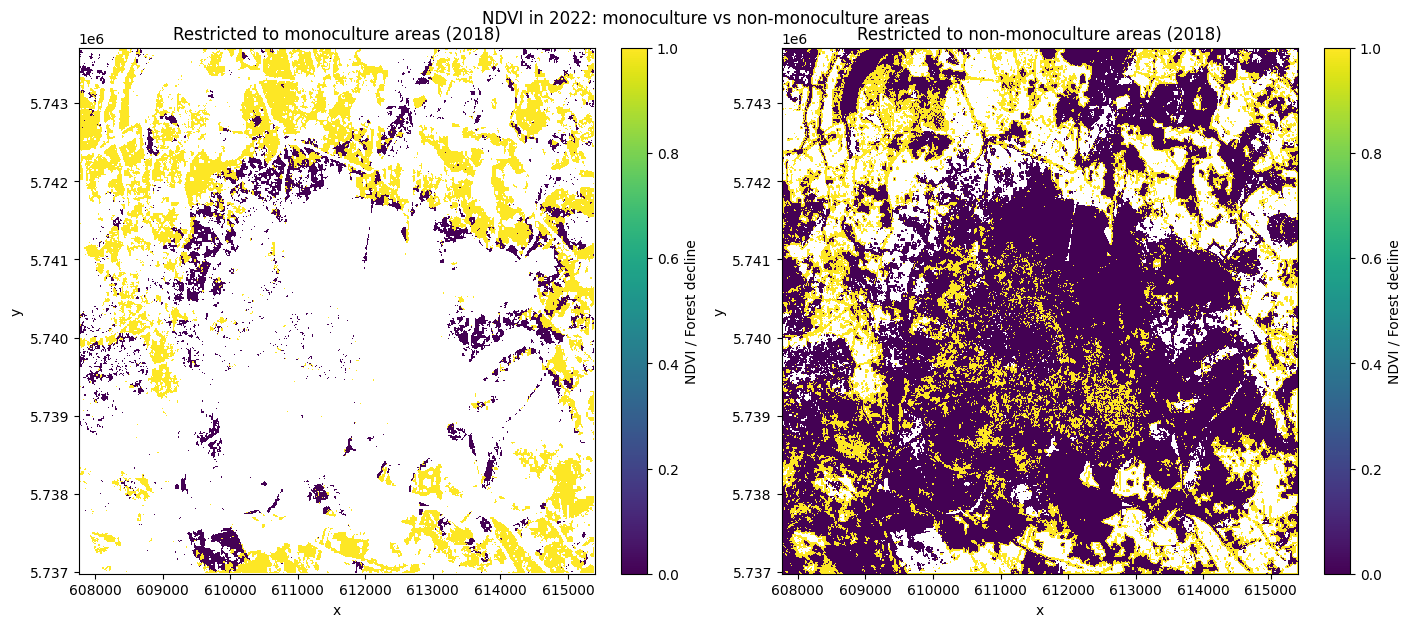

In [39]:
# --- Group: NDVI 2022 in monoculture vs non-monoculture areas ---
ndvi_with_monoculture_areas.load()
ndvi_with_non_monoculture_areas.load()

vmin = float(min(
    ndvi_with_monoculture_areas.quantile(0.02).values,
    ndvi_with_non_monoculture_areas.quantile(0.02).values
))
vmax = float(max(
    ndvi_with_monoculture_areas.quantile(0.98).values,
    ndvi_with_non_monoculture_areas.quantile(0.98).values
))

fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

ndvi_with_monoculture_areas.plot(
    ax=axes[0],
    cmap="viridis",
    vmin=vmin,
    vmax=vmax,
    cbar_kwargs={"label": "NDVI / Forest decline"}
)
axes[0].set_title("Restricted to monoculture areas (2018)")

ndvi_with_non_monoculture_areas.plot(
    ax=axes[1],
    cmap="viridis",
    vmin=vmin,
    vmax=vmax,
    cbar_kwargs={"label": "NDVI / Forest decline"}
)
axes[1].set_title("Restricted to non-monoculture areas (2018)")

plt.suptitle("NDVI in 2022: monoculture vs non-monoculture areas", fontsize=12, y=1.02)
plt.show()

## Results